# Alaska North Slope Base Map + Seismic + Wells Inventory

This notebook:
- builds a North Slope base map
- loads 2D seismic lines
- loads 3D seismic surveys
- loads well bottom-hole locations
- cleans and standardizes fields
- reprojects to EPSG:3338
- plots coverage layers
- exports cleaned parquet files

**Note:** these are inventory / categorical support layers, not yet the core geoscience property datasets.


In [1]:
import zipfile
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import box
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
def unzip_shapefile(zip_path):
    """Extract a zip file into a folder with the same stem and return that folder."""
    zip_path = Path(zip_path)
    extract_to = zip_path.parent / zip_path.stem
    extract_to.mkdir(exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_to)

    return extract_to


def list_extracted_files(folder):
    """Print extracted files for quick inspection."""
    folder = Path(folder)
    for p in folder.rglob("*"):
        print(p)


def find_first_shp(folder):
    """Return the first .shp file found under a folder."""
    folder = Path(folder)
    shp_files = sorted(folder.rglob("*.shp"))
    if not shp_files:
        raise FileNotFoundError(f"No .shp file found under {folder}")
    return shp_files[0]

In [3]:
def build_base_map():
    """Load a simple USA basemap and extract Alaska + North Slope study box."""
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

    usa = world[world["ADMIN"] == "United States of America"]
    usa_parts = usa.explode(index_parts=False)
    alaska = usa_parts[usa_parts.bounds.minx < -130].copy()

    north_slope_geom = box(-170, 68, -140, 71.8)
    north_slope = gpd.GeoDataFrame(
        {"name": ["North Slope Study Area"]},
        geometry=[north_slope_geom],
        crs="EPSG:4326",
    )

    return alaska, north_slope


def load_and_clean_2d(shp_path):
    """Load and standardize 2D seismic line data."""
    gdf = gpd.read_file(shp_path).copy()

    gdf["LineMiles"] = pd.to_numeric(gdf["LineMiles"], errors="coerce")
    gdf["ReleaseYea"] = pd.to_numeric(gdf["ReleaseYea"], errors="coerce")
    gdf["YearAcquir"] = pd.to_numeric(gdf["YearAcquir"], errors="coerce")

    gdf = gdf[
        ["CommonName", "YearAcquir", "ReleaseYea", "Processor", "LineMiles", "geometry"]
    ].copy()

    gdf = gdf.rename(
        columns={
            "CommonName": "survey_name",
            "YearAcquir": "year_acquired",
            "ReleaseYea": "year_released",
            "Processor": "company",
            "LineMiles": "line_miles",
        }
    )

    gdf["type"] = "2D"
    return gdf


def load_and_clean_3d(shp_path):
    """Load and standardize 3D seismic survey data."""
    gdf = gpd.read_file(shp_path).copy()

    gdf["SquareMile"] = pd.to_numeric(gdf["SquareMile"], errors="coerce")
    gdf["ReleaseYea"] = pd.to_numeric(gdf["ReleaseYea"], errors="coerce")
    gdf["YearAcquir"] = pd.to_numeric(gdf["YearAcquir"], errors="coerce")

    gdf = gdf[
        ["CommonName", "YearAcquir", "ReleaseYea", "Processor", "SquareMile", "SurveyType", "geometry"]
    ].copy()

    gdf = gdf.rename(
        columns={
            "CommonName": "survey_name",
            "YearAcquir": "year_acquired",
            "ReleaseYea": "year_released",
            "Processor": "company",
            "SquareMile": "square_miles",
            "SurveyType": "survey_type",
        }
    )

    gdf["type"] = "3D"
    return gdf


def load_well_locations(shp_path):
    """Load and standardize well bottom-hole location data."""
    gdf = gpd.read_file(shp_path).copy()

    rename_map = {
        "API Number": "api",
        "Well Name": "well_name",
        "Operator": "operator",
        "Field": "field",
        "Current Status": "status",
        "Geographic Area": "area",
    }

    keep_cols = [c for c in rename_map if c in gdf.columns] + ["geometry"]
    gdf = gdf[keep_cols].copy()
    gdf = gdf.rename(columns=rename_map)
    gdf["type"] = "well"

    return gdf

In [4]:
def reproject_for_mapping(alaska, north_slope, gdf_2d, gdf_3d, gdf_wells, epsg="EPSG:3338"):
    """Reproject all layers to a common CRS for plotting/export."""
    return (
        alaska.to_crs(epsg),
        north_slope.to_crs(epsg),
        gdf_2d.to_crs(epsg),
        gdf_3d.to_crs(epsg),
        gdf_wells.to_crs(epsg),
    )


def plot_all_layers(alaska_proj, north_slope_proj, gdf_2d_proj, gdf_3d_proj, gdf_wells_proj, focus=False):
    """Plot statewide or focused North Slope coverage with wells."""
    fig, ax = plt.subplots(figsize=(10, 7))

    alaska_proj.plot(ax=ax, color="whitesmoke", edgecolor="black")
    north_slope_proj.boundary.plot(ax=ax, color="black", linewidth=1.5)
    gdf_3d_proj.plot(ax=ax, color="deepskyblue", edgecolor="blue", alpha=0.5)
    gdf_2d_proj.plot(ax=ax, color="red", linewidth=0.7)
    gdf_wells_proj.plot(ax=ax, color="black", markersize=4, alpha=0.7)

    legend_elements = [
        Patch(facecolor="deepskyblue", edgecolor="blue", alpha=0.5, label="3D Seismic"),
        Line2D([0], [0], color="red", lw=2, label="2D Seismic"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markersize=6, label="Wells"),
        Line2D([0], [0], color="black", lw=1.5, label="North Slope Box"),
    ]
    ax.legend(handles=legend_elements, loc="lower left")

    if focus:
        minx, miny, maxx, maxy = north_slope_proj.total_bounds
        pad_x = (maxx - minx) * 0.05
        pad_y = (maxy - miny) * 0.05
        ax.set_xlim(minx - pad_x, maxx + pad_x)
        ax.set_ylim(miny - pad_y, maxy + pad_y)
        ax.set_title("North Slope Focus Area: Seismic + Wells Coverage")
    else:
        ax.set_title("Alaska North Slope: Seismic + Wells Coverage")

    plt.axis("off")
    plt.show()


def export_parquet_layers(gdf_2d_proj, gdf_3d_proj, gdf_wells_proj, out_dir="."):
    """Write clean projected outputs to parquet."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    out_2d = out_dir / "clean_2d_seismic.parquet"
    out_3d = out_dir / "clean_3d_seismic.parquet"
    out_wells = out_dir / "clean_well_locations.parquet"

    gdf_2d_proj.to_parquet(out_2d)
    gdf_3d_proj.to_parquet(out_3d)
    gdf_wells_proj.to_parquet(out_wells)

    print(f"Saved: {out_2d}")
    print(f"Saved: {out_3d}")
    print(f"Saved: {out_wells}")

In [5]:
ZIP_2D = "/home/jovyan/notebooks/raw_data/2d-seismic  lines/Tax_Credit_Seismic_2D.zip"
ZIP_3D = "/home/jovyan/notebooks/raw_data/3d-seismic lines/Tax_Credit_Seismic_3D.zip"
ZIP_WELLS = "/home/jovyan/notebooks/raw_data/Wells/Well_Bottom_Hole_Location.zip"

SHP_2D = "/home/jovyan/notebooks/raw_data/2d-seismic  lines/Tax_Credit_Seismic_2D/Tax_Credit_Seismic_2D.shp"
SHP_3D = "/home/jovyan/notebooks/raw_data/3d-seismic lines/Tax_Credit_Seismic_3D/Tax_Credit_Seismic_3D.shp"
SHP_WELLS = "/home/jovyan/notebooks/raw_data/Wells/Well_Bottom_Hole_Location/Well_Bottom_Hole_Location.shp"

OUTPUT_DIR = "."
TARGET_CRS = "EPSG:3338" 

In [6]:
alaska, north_slope = build_base_map()

extract_2d = unzip_shapefile(ZIP_2D)
extract_3d = unzip_shapefile(ZIP_3D)
extract_wells = unzip_shapefile(ZIP_WELLS)

gdf_2d = load_and_clean_2d(SHP_2D)
gdf_3d = load_and_clean_3d(SHP_3D)
gdf_wells = load_well_locations(SHP_WELLS)

print("2D rows:", len(gdf_2d))
print("3D rows:", len(gdf_3d))
print("Wells rows:", len(gdf_wells))

2D rows: 26
3D rows: 36
Wells rows: 10250


In [7]:
alaska_3338, north_slope_3338, gdf_2d_3338, gdf_3d_3338, gdf_wells_3338 = reproject_for_mapping(
    alaska, north_slope, gdf_2d, gdf_3d, gdf_wells, epsg=TARGET_CRS
)

In [8]:
display(gdf_2d_3338.head())
display(gdf_3d_3338.head())
display(gdf_wells_3338.head())

print("2D columns:", gdf_2d_3338.columns.tolist())
print("3D columns:", gdf_3d_3338.columns.tolist())
print("Wells columns:", gdf_wells_3338.columns.tolist())

,survey_name,year_acquired,year_released,company,line_miles,geometry,type
0,Pike Bottom Hole Planning 2D Reprocessing,NaN,2018.0,WesternGeco and CPA,153.75,"MULTILINESTRING ((236731.989 2285481.315, 2363...",2D
1,Stingray 2D,2011.0,2021.0,Northern Exploration Services LLC & Fairfield ...,2.24,"LINESTRING (119286.705 1207419.074, 119270.506...",2D
2,Nenana Basin 2D (2005),2005.0,2019.0,Weiman GeoScience & Geo Concepts Inc.,197.21,"MULTILINESTRING ((209578.634 1602304.698, 2095...",2D
3,White Hills 2D,2007.0,2017.0,Paradigm,170.42,"MULTILINESTRING ((160729.912 2182189.993, 1607...",2D
4,Moquawkie 2D,2004.0,2019.0,Veritas Geoservices,113.16,"MULTILINESTRING ((147194.545 1231707.825, 1471...",2D


,survey_name,year_acquired,year_released,company,square_miles,survey_type,geometry,type
0,"Aklaq, Smith Bay & Simpson 3D",2008,2019.0,WesternGeco,602.04,3D,"POLYGON ((-44307.807 2276329.172, -44321.591 2...",3D
1,Big Bend 3D,2014,2024.0,Geotrace Technologies,83.71,3D,"POLYGON ((118028.644 2220795.829, 117994.58 22...",3D
2,Big Island / North Island 3D (aka North Slope ...,2008,2019.0,CGG Veritas,199.39,3D,"POLYGON ((108559.168 2236399.912, 107975.721 2...",3D
3,Cook Inlet Tyonek 3D (R2),2012,2023.0,FairfieldNodal,122.29,3D,"MULTIPOLYGON (((153944.536 1244191.03, 153994....",3D
4,Cosmo 3D,2005,2018.0,WesternGeco,38.80,3D,"POLYGON ((112615.386 1092372.652, 117506.249 1...",3D


,operator,field,geometry,type
0,Romig Park Inc.,*EXPLORATORY,POINT (215783.293 1246044.842),well
1,Anchorage Oil and Development,*EXPLORATORY,POINT (226155.243 1254603.559),well
2,Union Oil Company of California,*EXPLORATORY,POINT (217961.219 1267479.561),well
3,Atlantic Richfield Company,*EXPLORATORY,POINT (213669.615 1263545.439),well
4,"ASRC Energy Services Alaska, Inc",*EXPLORATORY,POINT (222616.478 1278224.449),well


2D columns: ['survey_name', 'year_acquired', 'year_released', 'company', 'line_miles', 'geometry', 'type']
3D columns: ['survey_name', 'year_acquired', 'year_released', 'company', 'square_miles', 'survey_type', 'geometry', 'type']
Wells columns: ['operator', 'field', 'geometry', 'type']


In [9]:
# Optional: inspect extracted contents
list_extracted_files(extract_2d)
print("-" * 80)
list_extracted_files(extract_3d)
print("-" * 80)
list_extracted_files(extract_wells)

/home/jovyan/notebooks/raw_data/2d-seismic  lines/Tax_Credit_Seismic_2D/Tax_Credit_Seismic_2D.shp
/home/jovyan/notebooks/raw_data/2d-seismic  lines/Tax_Credit_Seismic_2D/Tax_Credit_Seismic_2D.prj
/home/jovyan/notebooks/raw_data/2d-seismic  lines/Tax_Credit_Seismic_2D/Tax_Credit_Seismic_2D.dbf
/home/jovyan/notebooks/raw_data/2d-seismic  lines/Tax_Credit_Seismic_2D/Tax_Credit_Seismic_2D.cpg
/home/jovyan/notebooks/raw_data/2d-seismic  lines/Tax_Credit_Seismic_2D/Tax_Credit_Seismic_2D.shx
/home/jovyan/notebooks/raw_data/2d-seismic  lines/Tax_Credit_Seismic_2D/Tax_Credit_Seismic_2D.xml
--------------------------------------------------------------------------------
/home/jovyan/notebooks/raw_data/3d-seismic lines/Tax_Credit_Seismic_3D/Tax_Credit_Seismic_3D.shp
/home/jovyan/notebooks/raw_data/3d-seismic lines/Tax_Credit_Seismic_3D/Tax_Credit_Seismic_3D.xml
/home/jovyan/notebooks/raw_data/3d-seismic lines/Tax_Credit_Seismic_3D/Tax_Credit_Seismic_3D.shx
/home/jovyan/notebooks/raw_data/3d-seism

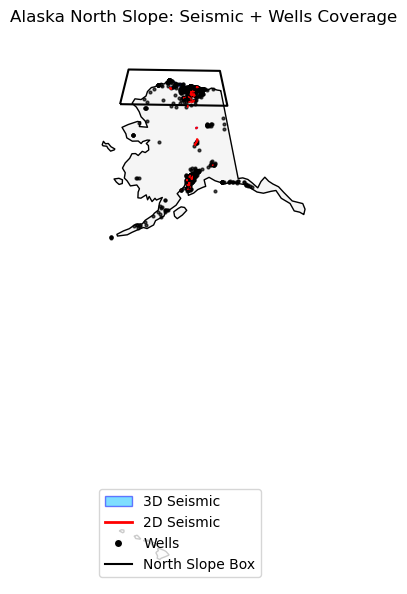

In [10]:
plot_all_layers(
    alaska_3338,
    north_slope_3338,
    gdf_2d_3338,
    gdf_3d_3338,
    gdf_wells_3338,
    focus=False,
)

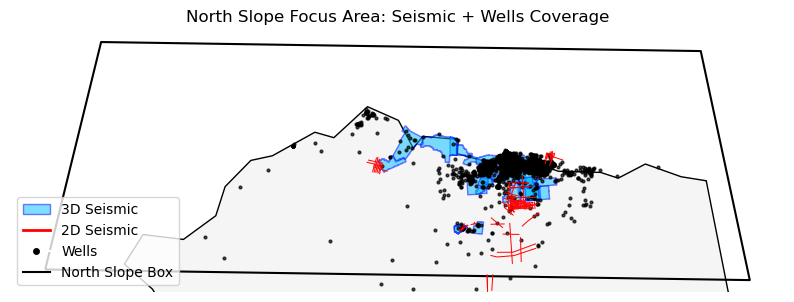

In [11]:
plot_all_layers(
    alaska_3338,
    north_slope_3338,
    gdf_2d_3338,
    gdf_3d_3338,
    gdf_wells_3338,
    focus=True,
)

In [12]:
export_parquet_layers(
    gdf_2d_3338,
    gdf_3d_3338,
    gdf_wells_3338,
    out_dir=OUTPUT_DIR,
)

Saved: clean_2d_seismic.parquet
Saved: clean_3d_seismic.parquet
Saved: clean_well_locations.parquet


In [13]:
# === SAVE BASE MAP LAYERS ===

alaska_3338 = alaska.to_crs("EPSG:3338")
north_slope_3338 = north_slope.to_crs("EPSG:3338")

alaska_3338.to_parquet("alaska_base_map.parquet")
north_slope_3338.to_parquet("north_slope_extent.parquet")

print("Saved base map layers")

Saved base map layers


## Notes / Next Steps

These layers are inventory and categorical support datasets.

Still needed for stronger internship relevance:
- well logs
- formation tops
- geologic maps
- property rasters / grids
- hydrate-related control datasets
- seismic-derived geoscience attributes


In [1]:
import pandas as pd
from shapely.geometry.base import BaseGeometry

def inspect_geometry_column(gdf, name="layer"):
    print(f"\n--- Inspecting {name} ---")
    print("rows:", len(gdf))
    print("crs:", gdf.crs)

    # raw python types in geometry column
    type_counts = gdf["geometry"].apply(lambda x: type(x).__name__).value_counts(dropna=False)
    print("\nGeometry python types:")
    print(type_counts)

    # rows that are null
    null_mask = gdf["geometry"].isna()
    print("\nNull geometry rows:", null_mask.sum())

    # rows that are not shapely geometry objects
    non_geom_mask = ~gdf["geometry"].apply(lambda x: isinstance(x, BaseGeometry) or pd.isna(x))
    print("Non-geometry rows:", non_geom_mask.sum())

    if non_geom_mask.sum() > 0:
        print("\nSample bad non-geometry rows:")
        display(gdf.loc[non_geom_mask].head(10))

    # valid shapely geometries only
    geom_mask = gdf["geometry"].apply(lambda x: isinstance(x, BaseGeometry))
    geom_only = gdf.loc[geom_mask].copy()

    print("\nGeometry types:")
    if len(geom_only) > 0:
        print(geom_only.geometry.geom_type.value_counts(dropna=False))
    else:
        print("No valid shapely geometries found.")

    empty_mask = geom_only.geometry.is_empty if len(geom_only) > 0 else pd.Series([], dtype=bool)
    print("\nEmpty geometry rows:", int(empty_mask.sum()) if len(geom_only) > 0 else 0)

    invalid_mask = ~geom_only.geometry.is_valid if len(geom_only) > 0 else pd.Series([], dtype=bool)
    print("Invalid geometry rows:", int(invalid_mask.sum()) if len(geom_only) > 0 else 0)

    if len(geom_only) > 0 and invalid_mask.sum() > 0:
        print("\nSample invalid geometry rows:")
        display(geom_only.loc[invalid_mask].head(10))

    return {
        "null_mask": null_mask,
        "non_geom_mask": non_geom_mask,
        "geom_mask": geom_mask,
        "geom_only": geom_only,
    }

In [2]:
inspect_geometry_column(gdf_3d, "gdf_3d")
inspect_geometry_column(gdf_3d_3338, "gdf_3d_3338")

NameError: name 'gdf_3d' is not defined